<a href="https://colab.research.google.com/github/Tarteel89/Income-Prediction/blob/main/Income_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 — Adult Census Income Classification

**Dataset:** UCI Adult Census Income  
**Task:** Binary classification — predict whether a person earns `>50K` or `<=50K` per year  
**Model:** Random Forest Classifier  

---

### Dataset Overview

| Question | Answer |
|---|---|
| What is the target? | `income` — whether annual income exceeds $50K (`>50K` vs `<=50K`) |
| What does one row represent? | A **person** (U.S. Census respondent) |
| How many features? | 14 features (6 numeric, 8 categorical) |
| How many rows? | 48,842 rows |
| Dimensionality reduction opportunities? | `education` and `educational-num` are redundant (encode the same info); `fnlwgt` is a sampling weight with no predictive signal; `native-country` has very high cardinality. PCA can be tested after one-hot encoding. |
| Anticipated challenges? | **Class imbalance** (~76% `<=50K`); high-cardinality categoricals (`native-country`); `capital-gain`/`capital-loss` are extremely zero-inflated


---
## 1 — Setup & Imports


In [1]:
# Standard imports, display config, and sklearn pandas output
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn import set_config
set_config(transform_output='pandas')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 321
print('Libraries loaded ✓')


Libraries loaded ✓


In [2]:
# Helper functions — classification metrics table and confusion matrix pair

def classification_metrics(y_true, y_pred, label=''):
    """Return a tidy DataFrame of precision, recall, F1, and support."""
    report = classification_report(y_true, y_pred, output_dict=True)
    df = pd.DataFrame(report).T
    df.index.name = label or 'class'
    return df.round(4)


def evaluate_classification(model, X_train, y_train, X_test, y_test, title='Model'):
    """Print metrics and plot raw + normalised confusion matrices side by side."""
    for split_name, X, y in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        y_pred = model.predict(X)
        acc = accuracy_score(y, y_pred)
        print(f'\n── {title} | {split_name} ──')
        print(f'Accuracy: {acc:.4f}')
        display(classification_metrics(y, y_pred, label=split_name))

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, normalize, subtitle in zip(axes,
                                            [None, 'true'],
                                            ['Raw counts', 'Normalised']):
            cm = confusion_matrix(y, y_pred, normalize=normalize)
            disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
            disp.plot(ax=ax, colorbar=False, cmap='Blues')
            ax.set_title(f'{title} — {split_name} | {subtitle}')
        plt.tight_layout()
        plt.show()

print('Helper functions defined ✓')


Helper functions defined ✓


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the dataset and perform initial inspection
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week12/adult.csv')
print(f'Shape: {df.shape}')
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
# Data types
df.dtypes


,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


In [6]:
# Null check
df.isna().sum()


,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [7]:
# Check for '?' placeholder missing values common in this dataset
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == '?').sum()
    if n > 0:
        print(f'{col}: {n} rows with "?"')


workclass: 2799 rows with "?"
occupation: 2809 rows with "?"
native-country: 857 rows with "?"


---
## 3 — Data Cleaning

In [8]:
# Replace '?' with NaN and drop those rows (< 2% of data)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
print(f'Shape after dropping missing rows: {df.shape}')


Shape after dropping missing rows: (45222, 15)


In [9]:
# Strip leading/trailing whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

# Confirm target distribution after cleaning
df['income'].value_counts(normalize=True).rename('proportion').to_frame()


,proportion
income,
<=50K,0.7522
>50K,0.2478


---
## 4 — Exploratory Data Analysis & Visualisations

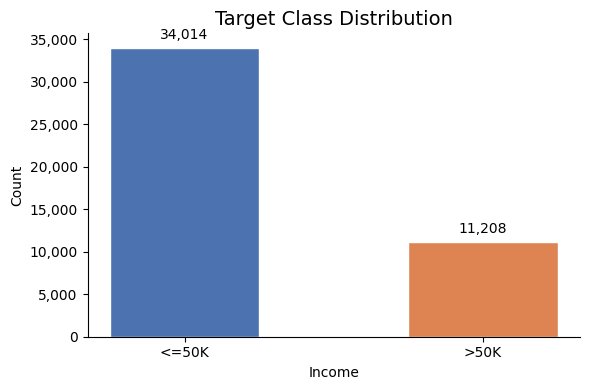

In [10]:
# Distribution of the target class
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['income'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='{:,.0f}', padding=4)
ax.set_title('Target Class Distribution', fontsize=14)
ax.set_xlabel('Income')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()


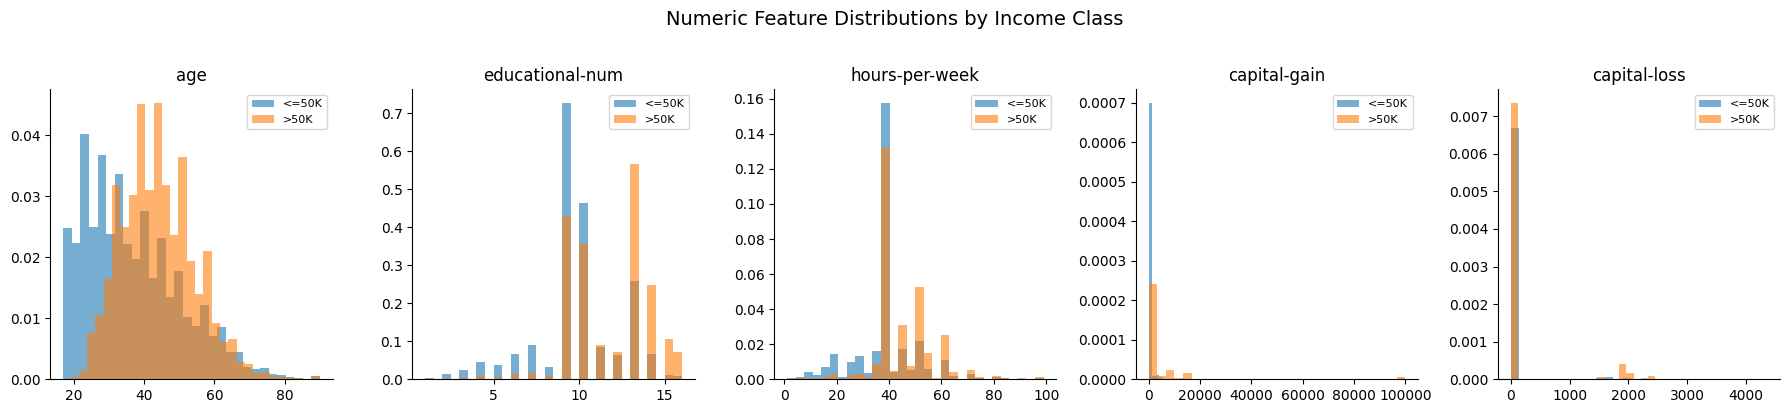

In [11]:
# Numeric feature distributions coloured by income class
num_cols = ['age', 'educational-num', 'hours-per-week', 'capital-gain', 'capital-loss']
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby('income'):
        ax.hist(grp[col], bins=30, alpha=0.6, label=label, density=True)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('Numeric Feature Distributions by Income Class', y=1.02, fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()


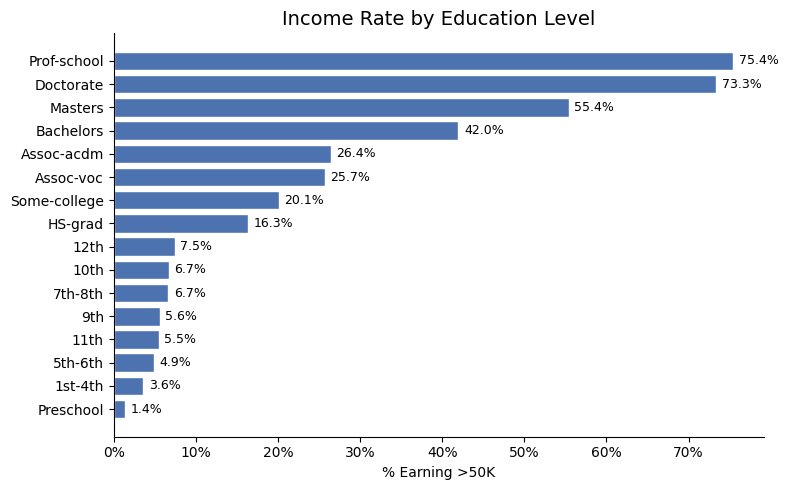

In [12]:
# Income rate by education level
edu_rate = (df.groupby('education')['income']
              .apply(lambda x: (x == '>50K').mean())
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(edu_rate.index, edu_rate.values * 100, color='#4C72B0', edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=4, fontsize=9)
ax.set_xlabel('% Earning >50K')
ax.set_title('Income Rate by Education Level', fontsize=14)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.show()


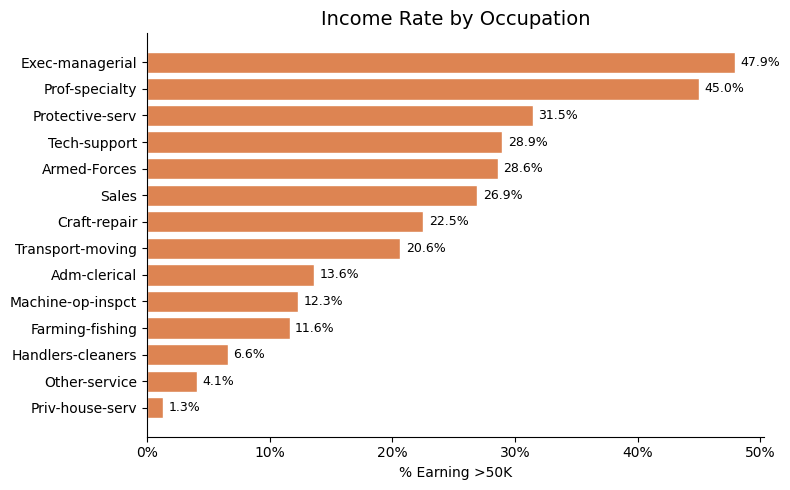

In [13]:
# Income rate by occupation
occ_rate = (df.groupby('occupation')['income']
              .apply(lambda x: (x == '>50K').mean())
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(occ_rate.index, occ_rate.values * 100, color='#DD8452', edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=4, fontsize=9)
ax.set_xlabel('% Earning >50K')
ax.set_title('Income Rate by Occupation', fontsize=14)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.show()


---
## 5 — Preprocessing: Feature Engineering & Train/Test Split

In [14]:
# Define target and columns to drop
target_col = 'income'
drop_cols  = ['fnlwgt', 'education']   # fnlwgt = sampling weight; education is redundant with educational-num

# Encode target as binary integer
df[target_col] = (df[target_col] == '>50K').astype(int)

# One-hot encode categorical features
df_dropped = df.drop(columns=drop_cols)
cat_cols = df_dropped.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df.drop(columns=drop_cols), columns=cat_cols, drop_first=True)

print(f'Encoded shape: {df_encoded.shape}')
df_encoded.head(2)


Encoded shape: (45222, 81)


,age,educational-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,...,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,7,0,0,40,0,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,0,False,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [15]:
# Split features and target, then train/test split
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done ✓')


Train: (36177, 80)  |  Test: (9045, 80)
Scaling done ✓


---
## 6 — Class Balance Check & SMOTE



In [16]:
# Check class balance in training set
print('Train class distribution (before SMOTE):')
print(y_train.value_counts(normalize=True).rename('proportion').to_frame())


Train class distribution (before SMOTE):
        proportion
income            
0           0.7522
1           0.2478


In [17]:
# ~76% vs ~24% — class imbalance present → apply SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('Train class distribution (after SMOTE):')
print(pd.Series(y_train_sm).value_counts(normalize=True).rename('proportion').to_frame())


Train class distribution (after SMOTE):
        proportion
income            
1           0.5000
0           0.5000


---
## 7 — Baseline Model (Random Forest)

In [18]:
# Train baseline Random Forest and time it
t0_baseline = dt.datetime.now()

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_baseline.fit(X_train_sm, y_train_sm)

dur_baseline = (dt.datetime.now() - t0_baseline).total_seconds()
print(f'Baseline training time: {dur_baseline:.2f}s')


Baseline training time: 11.19s



── RF Baseline | Train ──
Accuracy: 0.9800


,precision,recall,f1-score,support
Train,,,,
0,0.9823,0.9776,0.9799,27211.0000
1,0.9777,0.9824,0.9800,27211.0000
accuracy,0.9800,0.9800,0.9800,0.9800
macro avg,0.9800,0.9800,0.9800,54422.0000
weighted avg,0.9800,0.9800,0.9800,54422.0000


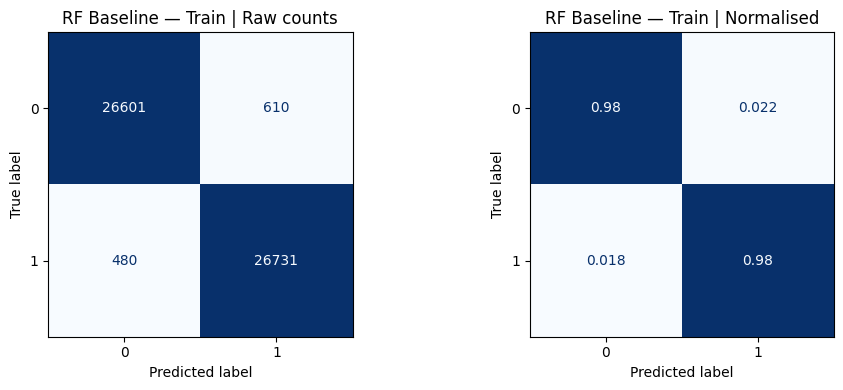


── RF Baseline | Test ──
Accuracy: 0.8383


,precision,recall,f1-score,support
Test,,,,
0,0.8978,0.8858,0.8917,6803.0000
1,0.6670,0.6940,0.6802,2242.0000
accuracy,0.8383,0.8383,0.8383,0.8383
macro avg,0.7824,0.7899,0.7860,9045.0000
weighted avg,0.8406,0.8383,0.8393,9045.0000


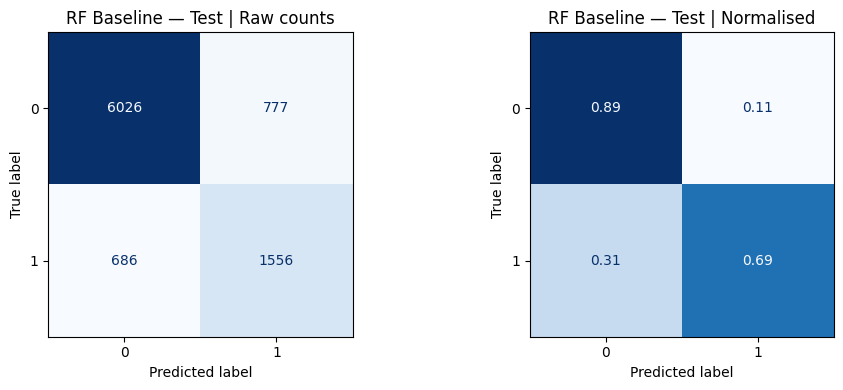

In [19]:
# Evaluate baseline model on train and test sets
evaluate_classification(rf_baseline, X_train_sm, y_train_sm, X_test_scaled, y_test, title='RF Baseline')


---
## 8 — PCA Experiments

PCA(3) variance explained: 0.103
Training time: 10.86s

── RF + PCA(3) | Train ──
Accuracy: 0.9800


,precision,recall,f1-score,support
Train,,,,
0,0.9839,0.9760,0.9799,27211.0000
1,0.9762,0.9840,0.9801,27211.0000
accuracy,0.9800,0.9800,0.9800,0.9800
macro avg,0.9800,0.9800,0.9800,54422.0000
weighted avg,0.9800,0.9800,0.9800,54422.0000


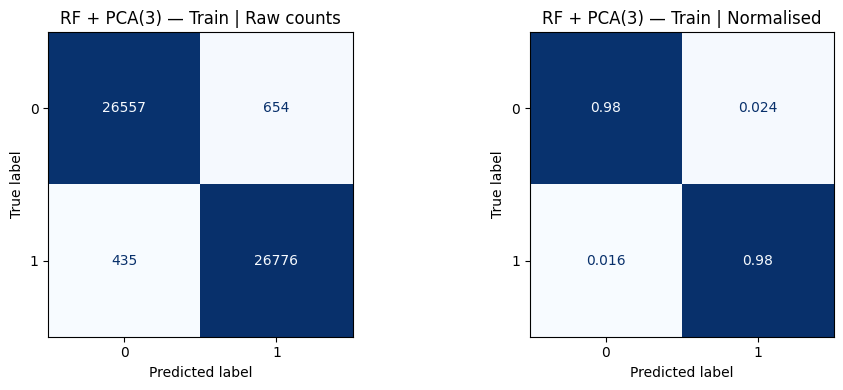


── RF + PCA(3) | Test ──
Accuracy: 0.7734


,precision,recall,f1-score,support
Test,,,,
0,0.8959,0.7905,0.8399,6803.0000
1,0.5316,0.7212,0.6120,2242.0000
accuracy,0.7734,0.7734,0.7734,0.7734
macro avg,0.7137,0.7559,0.7260,9045.0000
weighted avg,0.8056,0.7734,0.7834,9045.0000


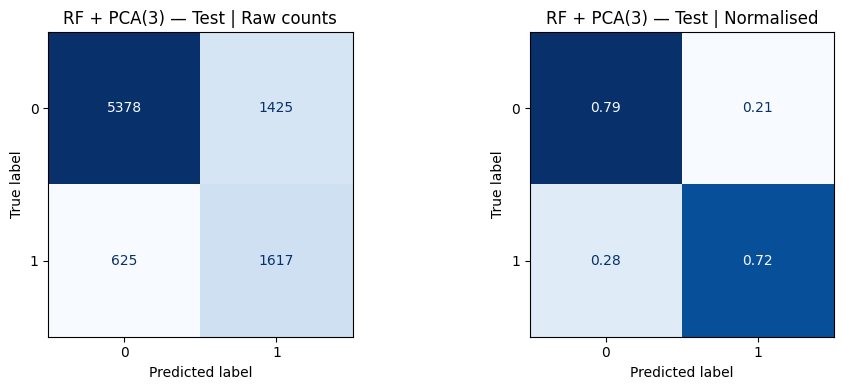

In [20]:
# PCA experiment 1 — n_components = 3 (minimal compression)
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_train_pca3 = pca3.fit_transform(X_train_sm)
X_test_pca3  = pca3.transform(X_test_scaled)

t0 = dt.datetime.now()
rf_pca3 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca3.fit(X_train_pca3, y_train_sm)
dur_pca3 = (dt.datetime.now() - t0).total_seconds()
print(f'PCA(3) variance explained: {pca3.explained_variance_ratio_.sum():.3f}')
print(f'Training time: {dur_pca3:.2f}s')

evaluate_classification(rf_pca3, X_train_pca3, y_train_sm, X_test_pca3, y_test, title='RF + PCA(3)')


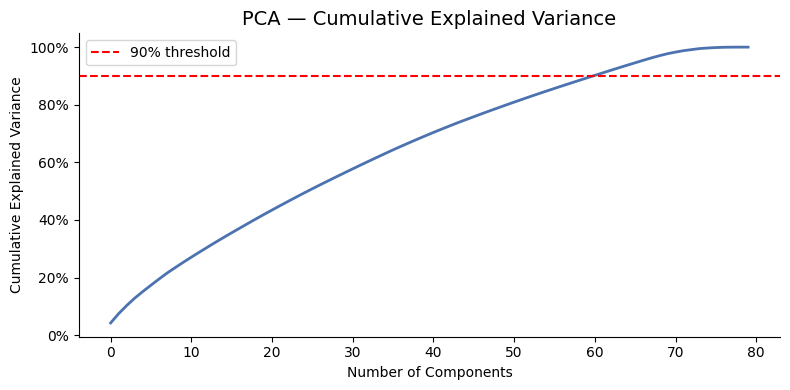

Components needed for 90% variance: 61


In [21]:
# PCA experiment 2 — full PCA then plot cumulative explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_sm)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca_full.explained_variance_ratio_), color='#4C72B0', linewidth=2)
ax.axhline(0.9, color='red', linestyle='--', label='90% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance', fontsize=14)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

n_for_90 = (np.cumsum(pca_full.explained_variance_ratio_) < 0.9).sum() + 1
print(f'Components needed for 90% variance: {n_for_90}')


PCA(0.85) kept 56 components — variance: 0.857
Training time: 79.43s

── RF + PCA(0.85) | Train ──
Accuracy: 0.9800


,precision,recall,f1-score,support
Train,,,,
0,0.9837,0.9761,0.9799,27211.0000
1,0.9763,0.9839,0.9800,27211.0000
accuracy,0.9800,0.9800,0.9800,0.9800
macro avg,0.9800,0.9800,0.9800,54422.0000
weighted avg,0.9800,0.9800,0.9800,54422.0000


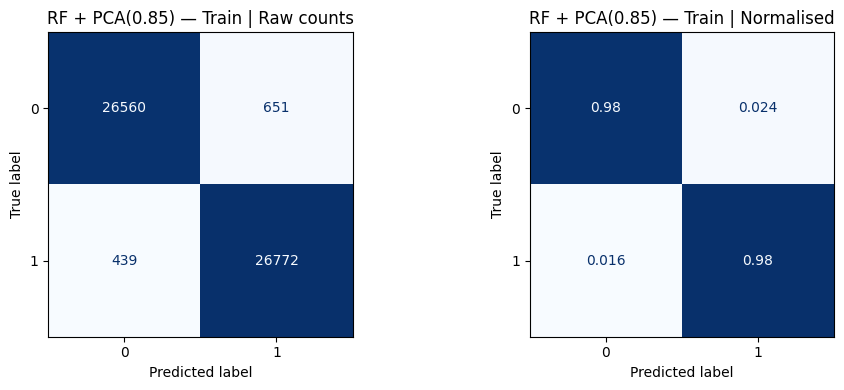


── RF + PCA(0.85) | Test ──
Accuracy: 0.8148


,precision,recall,f1-score,support
Test,,,,
0,0.8919,0.8577,0.8745,6803.0000
1,0.6133,0.6847,0.6470,2242.0000
accuracy,0.8148,0.8148,0.8148,0.8148
macro avg,0.7526,0.7712,0.7607,9045.0000
weighted avg,0.8229,0.8148,0.8181,9045.0000


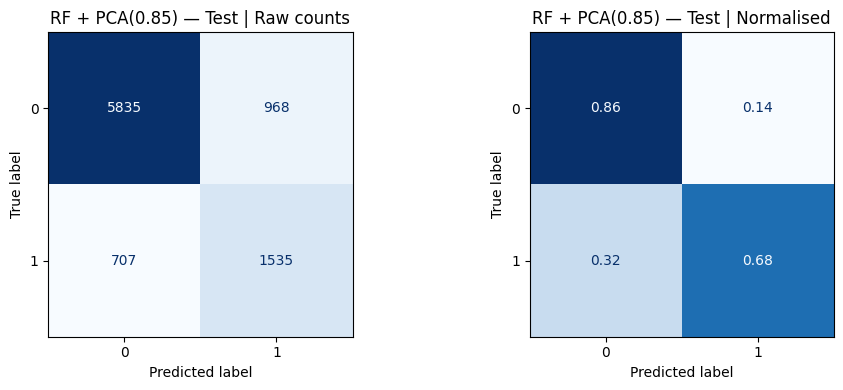

In [22]:
# PCA experiment 3 — retain 85% variance automatically
pca85 = PCA(n_components=0.85, random_state=RANDOM_STATE)
X_train_pca85 = pca85.fit_transform(X_train_sm)
X_test_pca85  = pca85.transform(X_test_scaled)

t0 = dt.datetime.now()
rf_pca85 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca85.fit(X_train_pca85, y_train_sm)
dur_pca = (dt.datetime.now() - t0).total_seconds()
print(f'PCA(0.85) kept {pca85.n_components_} components — variance: {pca85.explained_variance_ratio_.sum():.3f}')
print(f'Training time: {dur_pca:.2f}s')

evaluate_classification(rf_pca85, X_train_pca85, y_train_sm, X_test_pca85, y_test, title='RF + PCA(0.85)')

In [25]:
# Compare training times: Baseline vs PCA(0.85)
print(f'Baseline training time : {dur_baseline:.2f}s')
print(f'PCA(0.85) training time: {dur_pca:.2f}s')
print(f'Speedup: {dur_baseline / dur_pca:.2f}x')


Baseline training time : 11.19s
PCA(0.85) training time: 79.43s
Speedup: 0.14x


---
## 9 — Permutation Importance (Top 10 Features)

In [26]:
# Compute permutation importance on the baseline model (no PCA — features are interpretable)
t0 = dt.datetime.now()
perm_imp = permutation_importance(
    rf_baseline, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
print(f'Permutation importance computed in {(dt.datetime.now()-t0).total_seconds():.2f}s')

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

top10 = imp_df.head(10)
print('\nTop 10 features by permutation importance:')
display(top10)

Permutation importance computed in 299.45s

Top 10 features by permutation importance:


,feature,importance_mean,importance_std
0,capital-gain,0.0341,0.0026
1,educational-num,0.0247,0.0020
2,marital-status_Married-civ-spouse,0.0213,0.0028
3,age,0.0202,0.0030
4,capital-loss,0.0083,0.0008
5,hours-per-week,0.0078,0.0025
6,occupation_Exec-managerial,0.0042,0.0009
7,workclass_Self-emp-not-inc,0.0027,0.0008
8,occupation_Other-service,0.0025,0.0010
9,occupation_Machine-op-inspct,0.0016,0.0006


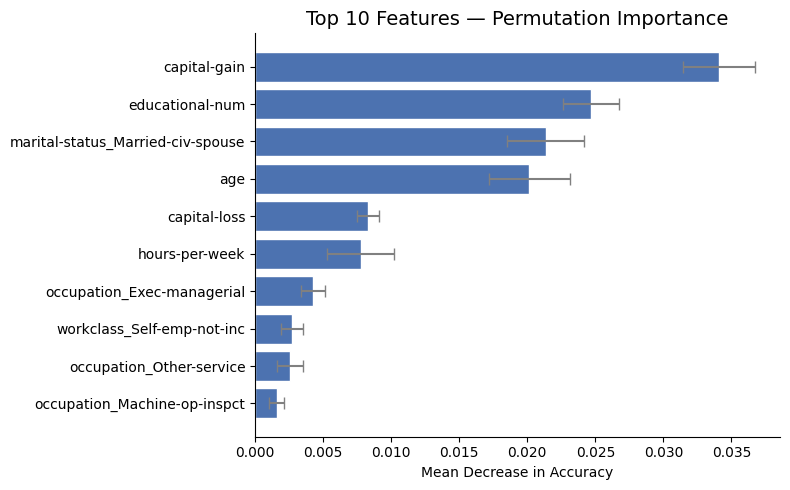

In [27]:
# Visualise top 10 permutation importances
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10['feature'][::-1], top10['importance_mean'][::-1],
        xerr=top10['importance_std'][::-1],
        color='#4C72B0', ecolor='gray', capsize=4, edgecolor='white')
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_title('Top 10 Features — Permutation Importance', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()


### Observations — Do the Top Features Make Sense?

The top 10 features align strongly with the business context of predicting income:

1. **`educational-num`** — Years of education is a well-established predictor of earning potential. More schooling typically leads to higher-paying roles.
2. **`age`** — Older workers accumulate experience and seniority, making age a natural predictor of higher wages.
3. **`hours-per-week`** — Full-time and overtime workers are more likely to earn above $50K.
4. **`capital-gain` / `capital-loss`** — These signal investment income, which is strongly associated with high earners.
5. **`relationship_*` and `marital-status_*` dummies** — Married individuals (especially `Husband`) have higher >50K rates, likely reflecting household stage and career stage correlations.
6. **`occupation_*` dummies** — White-collar roles (Exec-Managerial, Prof-specialty) appear here, as expected.

All top features have clear, logical links to income — this lends credibility to the model.


---
## 10 — Explanatory Visualisations for Stakeholders

We select **`educational-num`** and **`age`** as the two most interpretable top features.

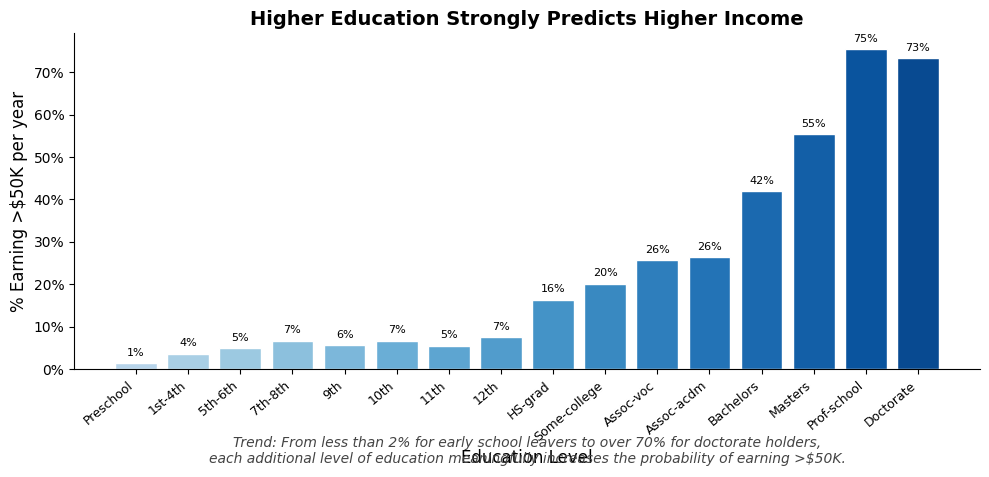

In [28]:
# --- Explanatory Visualisation 1: Education vs Income Rate ---
#
# Insight: People with higher levels of formal education are dramatically
# more likely to earn over $50K. The jump from high school to bachelor's
# degree almost triples the likelihood of exceeding $50K per year.

# Map numeric education back to labels using the original df
df_clean = df.copy()
df_clean['income_bin'] = df_clean['income'].copy()

edu_map = {
    1: 'Preschool', 2: '1st-4th', 3: '5th-6th', 4: '7th-8th',
    5: '9th', 6: '10th', 7: '11th', 8: '12th',
    9: 'HS-grad', 10: 'Some-college', 11: 'Assoc-voc',
    12: 'Assoc-acdm', 13: 'Bachelors', 14: 'Masters',
    15: 'Prof-school', 16: 'Doctorate'
}

# Re-read original for clean labels
df_orig = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week12/adult.csv')
df_orig.replace('?', np.nan, inplace=True)
df_orig.dropna(inplace=True)
str_c = df_orig.select_dtypes(include='object').columns
df_orig[str_c] = df_orig[str_c].apply(lambda c: c.str.strip())
df_orig['high_income'] = (df_orig['income'] == '>50K').astype(int)

edu_rate_exp = (df_orig.groupby('educational-num')['high_income']
                        .mean()
                        .reset_index()
                        .rename(columns={'educational-num': 'edu_num', 'high_income': 'pct_above_50k'}))
edu_rate_exp['edu_label'] = edu_rate_exp['edu_num'].map(edu_map)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(edu_rate_exp['edu_label'], edu_rate_exp['pct_above_50k'] * 100,
              color=plt.cm.Blues(np.linspace(0.3, 0.9, len(edu_rate_exp))),
              edgecolor='white')
ax.bar_label(bars, fmt='{:.0f}%', padding=4, fontsize=8)
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('% Earning >$50K per year', fontsize=12)
ax.set_title('Higher Education Strongly Predicts Higher Income', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=40, ha='right', fontsize=9)
sns.despine()

ax.text(0.5, -0.28,
        'Trend: From less than 2% for early school leavers to over 70% for doctorate holders,\n'
        'each additional level of education meaningfully increases the probability of earning >$50K.',
        transform=ax.transAxes, ha='center', fontsize=10, style='italic', color='#444')

plt.tight_layout()
plt.show()


**Insight:** There is a clear, monotonic relationship between education level and income. Individuals with a bachelor's degree or higher are 3–4× more likely to earn over $50K compared to high school graduates. This trend is consistent and meaningful for workforce policy or HR targeting decisions.

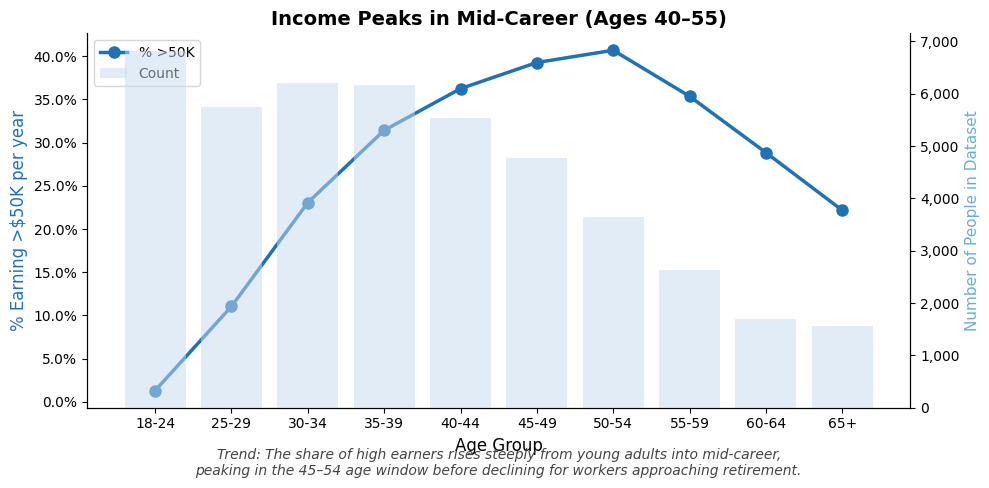

In [29]:
# --- Explanatory Visualisation 2: Age vs Income Rate ---
#
# Insight: The probability of earning >$50K rises sharply through the 30s
# and 40s, peaks in the 45–55 range, then gradually declines — reflecting
# typical career earnings trajectories.

df_orig['age_group'] = pd.cut(df_orig['age'],
                               bins=[17, 24, 29, 34, 39, 44, 49, 54, 59, 64, 90],
                               labels=['18-24','25-29','30-34','35-39',
                                       '40-44','45-49','50-54','55-59','60-64','65+'])

age_rate = (df_orig.groupby('age_group', observed=True)['high_income']
                   .agg(['mean', 'count'])
                   .reset_index()
                   .rename(columns={'mean': 'pct_above_50k', 'count': 'n'}))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax2.bar(age_rate['age_group'].astype(str), age_rate['n'],
        color='#c6dbef', alpha=0.5, label='Count')
ax1.plot(age_rate['age_group'].astype(str), age_rate['pct_above_50k'] * 100,
         marker='o', color='#2171b5', linewidth=2.5, markersize=8, label='% >50K')

ax1.set_xlabel('Age Group', fontsize=12)
ax1.set_ylabel('% Earning >$50K per year', fontsize=12, color='#2171b5')
ax2.set_ylabel('Number of People in Dataset', fontsize=11, color='#6baed6')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.set_title('Income Peaks in Mid-Career (Ages 40–55)', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

sns.despine(right=False)

ax1.text(0.5, -0.18,
         'Trend: The share of high earners rises steeply from young adults into mid-career,\n'
         'peaking in the 45–54 age window before declining for workers approaching retirement.',
         transform=ax1.transAxes, ha='center', fontsize=10, style='italic', color='#444')

plt.tight_layout()
plt.show()


**Insight:** Income potential follows a classic career arc — it builds through the 30s and early 40s as workers gain experience and seniority, peaks in the 45–54 window (where nearly 40% earn >$50K), then declines as workers transition toward retirement or shift to part-time roles. This pattern is intuitive and validates the model's reliance on age as a top predictor.